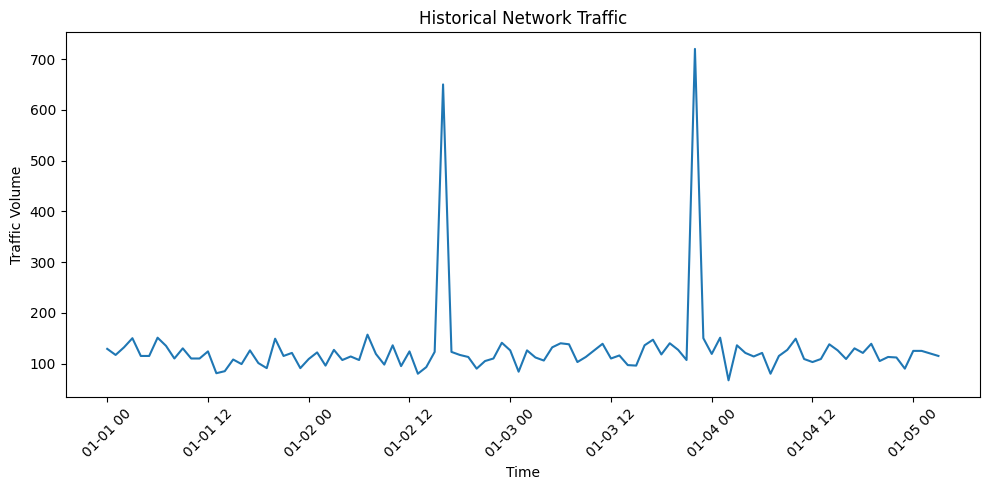

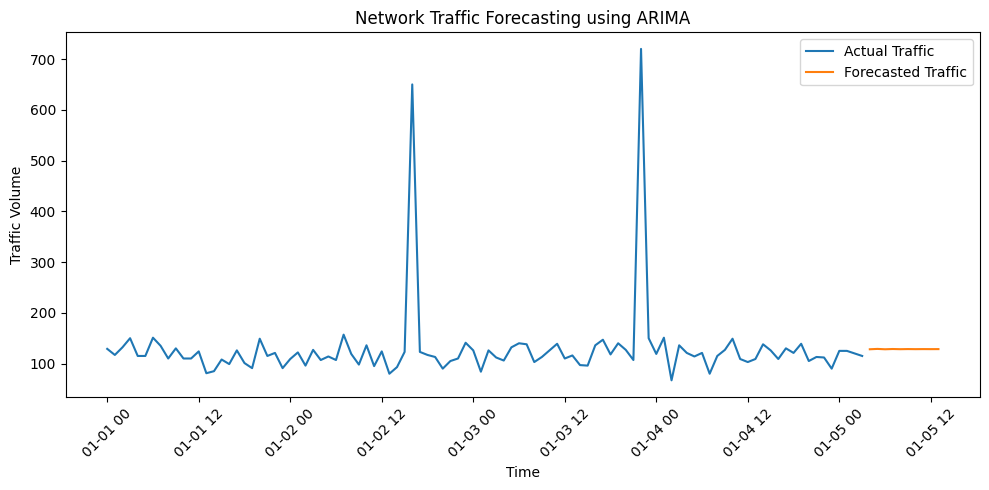

2026-01-05 04:00:00 - Normal Traffic
2026-01-05 05:00:00 - Normal Traffic
2026-01-05 06:00:00 - Normal Traffic
2026-01-05 07:00:00 - Normal Traffic
2026-01-05 08:00:00 - Normal Traffic
2026-01-05 09:00:00 - Normal Traffic
2026-01-05 10:00:00 - Normal Traffic
2026-01-05 11:00:00 - Normal Traffic
2026-01-05 12:00:00 - Normal Traffic
2026-01-05 13:00:00 - Normal Traffic


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
# Create simple sample network traffic dataset
np.random.seed(42)

dates = pd.date_range(start='2026-01-01', periods=100, freq='h')
traffic = np.random.normal(loc=120, scale=20, size=100).astype(int)

# Add artificial DDoS-like spikes
traffic[40] = 650
traffic[70] = 720

data = pd.DataFrame({
    'timestamp': dates,
    'traffic_volume': traffic
})

data.to_csv('network_traffic.csv', index=False)
data.head()
# Load dataset
data = pd.read_csv('network_traffic.csv')
data['timestamp'] = pd.to_datetime(data['timestamp'])
data.set_index('timestamp', inplace=True)
data = data.asfreq('h')

data.head()
# Plot historical network traffic
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['traffic_volume'])
plt.title('Historical Network Traffic')
plt.xlabel('Time')
plt.ylabel('Traffic Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Train ARIMA model
model = ARIMA(data['traffic_volume'], order=(2, 1, 2))
model_fit = model.fit()
# Forecast next 10 hours
forecast_steps = 10
forecast = model_fit.forecast(steps=forecast_steps)

future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(hours=1),
    periods=forecast_steps,
    freq='h'
)

forecast_df = pd.DataFrame({
    'timestamp': future_dates,
    'forecasted_traffic': forecast.values
})

forecast_df
# Plot actual and forecasted traffic
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['traffic_volume'], label='Actual Traffic')
plt.plot(forecast_df['timestamp'], forecast_df['forecasted_traffic'], label='Forecasted Traffic')
plt.title('Network Traffic Forecasting using ARIMA')
plt.xlabel('Time')
plt.ylabel('Traffic Volume')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Detect possible DDoS attack based on threshold
threshold = 500

forecast_df['status'] = forecast_df['forecasted_traffic'].apply(
    lambda x: 'Possible DDoS Attack' if x > threshold else 'Normal Traffic'
)

forecast_df
# Print alerts
for _, row in forecast_df.iterrows():
    print(row['timestamp'], '-', row['status'])
